# Portafolio Cuantitativo Neutral al Mercado

## Pairs Trading en Forex mediante Cointegración y Filtro de Kalman

**Autor:** Edgar Samuel Oropeza García

**Institución:** Tec de Monterrey

**Área:** Finanzas Cuantitativas, Economía Estadística y Machine Learning

---

Este notebook implementa, paso a paso, un sistema de *Pairs Trading* (arbitraje estadístico) sobre el mercado de divisas (Forex). El objetivo es identificar pares de monedas cointegradas, estimar su relación de cobertura de forma dinámica con un Filtro de Kalman, y generar señales de entrada/salida basadas en la reversión a la media del spread — buscando retornos independientes de la dirección general del mercado (*market-neutral*).

## Instalación de Librerías

Se instalan las librerías necesarias para cada fase del proyecto. Las marcadas como opcionales corresponden a la extensión GNN (alternativa a TDA), que no es parte obligatoria del pipeline base.

In [1]:
# Fase 1
# %pip install yfinance oandapyV20 pandas numpy
# %pip install --upgrade yfinance

# Fase 2
# %pip install statsmodels scipy scikit-learn gudhi ripser kmapper networkx

# Fase 3
# %pip install pykalman filterpy

# Fase 4
# %pip install hmmlearn

# Fase 5
# %pip install vectorbt quantstats empyrical-reloaded

# Opcional — GNN (alternativa a TDA en Fase 2)
# %pip install torch torch-geometric

## Fase 1: Datos y EDA

Descargamos los precios históricos de las divisas del universo (12 monedas frente al USD), los alineamos en el tiempo y separamos cronológicamente en entrenamiento (in-sample) y validación (out-of-sample). Esta separación es clave: todo lo que se calibre en las fases siguientes (cointegración, umbrales, Kalman) se hace con el tramo de entrenamiento, para que el tramo de validación sirva como una prueba honesta.

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

pd.set_option('display.max_columns', None)

# Universo de 12 divisas de alta liquidez, expresadas como pares contra USD (formato yfinance)
tickers = {
    'EURUSD': 'EURUSD=X',
    'GBPUSD': 'GBPUSD=X',
    'AUDUSD': 'AUDUSD=X',
    'NZDUSD': 'NZDUSD=X',
    'USDJPY': 'USDJPY=X',
    'USDCAD': 'USDCAD=X',
    'USDCHF': 'USDCHF=X',
    'USDMXN': 'USDMXN=X',
    'USDCNY': 'USDCNY=X',
    'USDSEK': 'USDSEK=X',
    'USDNOK': 'USDNOK=X',
    'USDSGD': 'USDSGD=X',
}

In [3]:
# yfinance limita los intervalos de 60m a los últimos ~730 días
raw_data = yf.download(
    list(tickers.values()),
    period='729d',
    interval='60m',
    progress=False
)['Close']

raw_data.columns = tickers.keys()
raw_data.head()

,EURUSD,GBPUSD,AUDUSD,NZDUSD,USDJPY,USDCAD,USDCHF,USDMXN,USDCNY,USDSEK,USDNOK,USDSGD
Datetime,,,,,,,,,,,,
2023-11-23 00:00:00+00:00,0.655050,1.089562,1.249641,0.603173,1.36820,0.88358,7.1545,149.259003,17.192961,10.75248,10.46201,1.34121
2023-11-23 01:00:00+00:00,0.655480,1.089800,1.249578,0.604230,1.36866,0.88319,7.1534,149.173996,17.184000,10.75500,10.45170,1.34158
2023-11-23 02:00:00+00:00,0.655652,1.090631,1.250391,0.605254,1.36821,0.88279,7.1439,149.119995,17.189199,10.74331,10.44316,1.34072
2023-11-23 03:00:00+00:00,0.655781,1.090750,1.250610,0.605290,1.36800,0.88254,7.1418,149.123993,17.188999,10.74038,10.44215,1.34071
2023-11-23 04:00:00+00:00,0.655437,1.090513,1.250328,0.605071,1.36813,0.88292,7.1435,149.158005,17.189600,10.74128,10.44373,1.34083


In [4]:
# Forex opera 24/5; puede haber pequeños huecos entre calendarios de distintos pares.
data = raw_data.copy().ffill().dropna()

print(f"Rango de fechas: {data.index.min()} a {data.index.max()}")
print(f"Número de observaciones: {len(data)}")
data.head()

Rango de fechas: 2023-11-23 00:00:00+00:00 a 2026-09-08 00:00:00+01:00
Número de observaciones: 17351


,EURUSD,GBPUSD,AUDUSD,NZDUSD,USDJPY,USDCAD,USDCHF,USDMXN,USDCNY,USDSEK,USDNOK,USDSGD
Datetime,,,,,,,,,,,,
2023-11-23 00:00:00+00:00,0.655050,1.089562,1.249641,0.603173,1.36820,0.88358,7.1545,149.259003,17.192961,10.75248,10.46201,1.34121
2023-11-23 01:00:00+00:00,0.655480,1.089800,1.249578,0.604230,1.36866,0.88319,7.1534,149.173996,17.184000,10.75500,10.45170,1.34158
2023-11-23 02:00:00+00:00,0.655652,1.090631,1.250391,0.605254,1.36821,0.88279,7.1439,149.119995,17.189199,10.74331,10.44316,1.34072
2023-11-23 03:00:00+00:00,0.655781,1.090750,1.250610,0.605290,1.36800,0.88254,7.1418,149.123993,17.188999,10.74038,10.44215,1.34071
2023-11-23 04:00:00+00:00,0.655437,1.090513,1.250328,0.605071,1.36813,0.88292,7.1435,149.158005,17.189600,10.74128,10.44373,1.34083


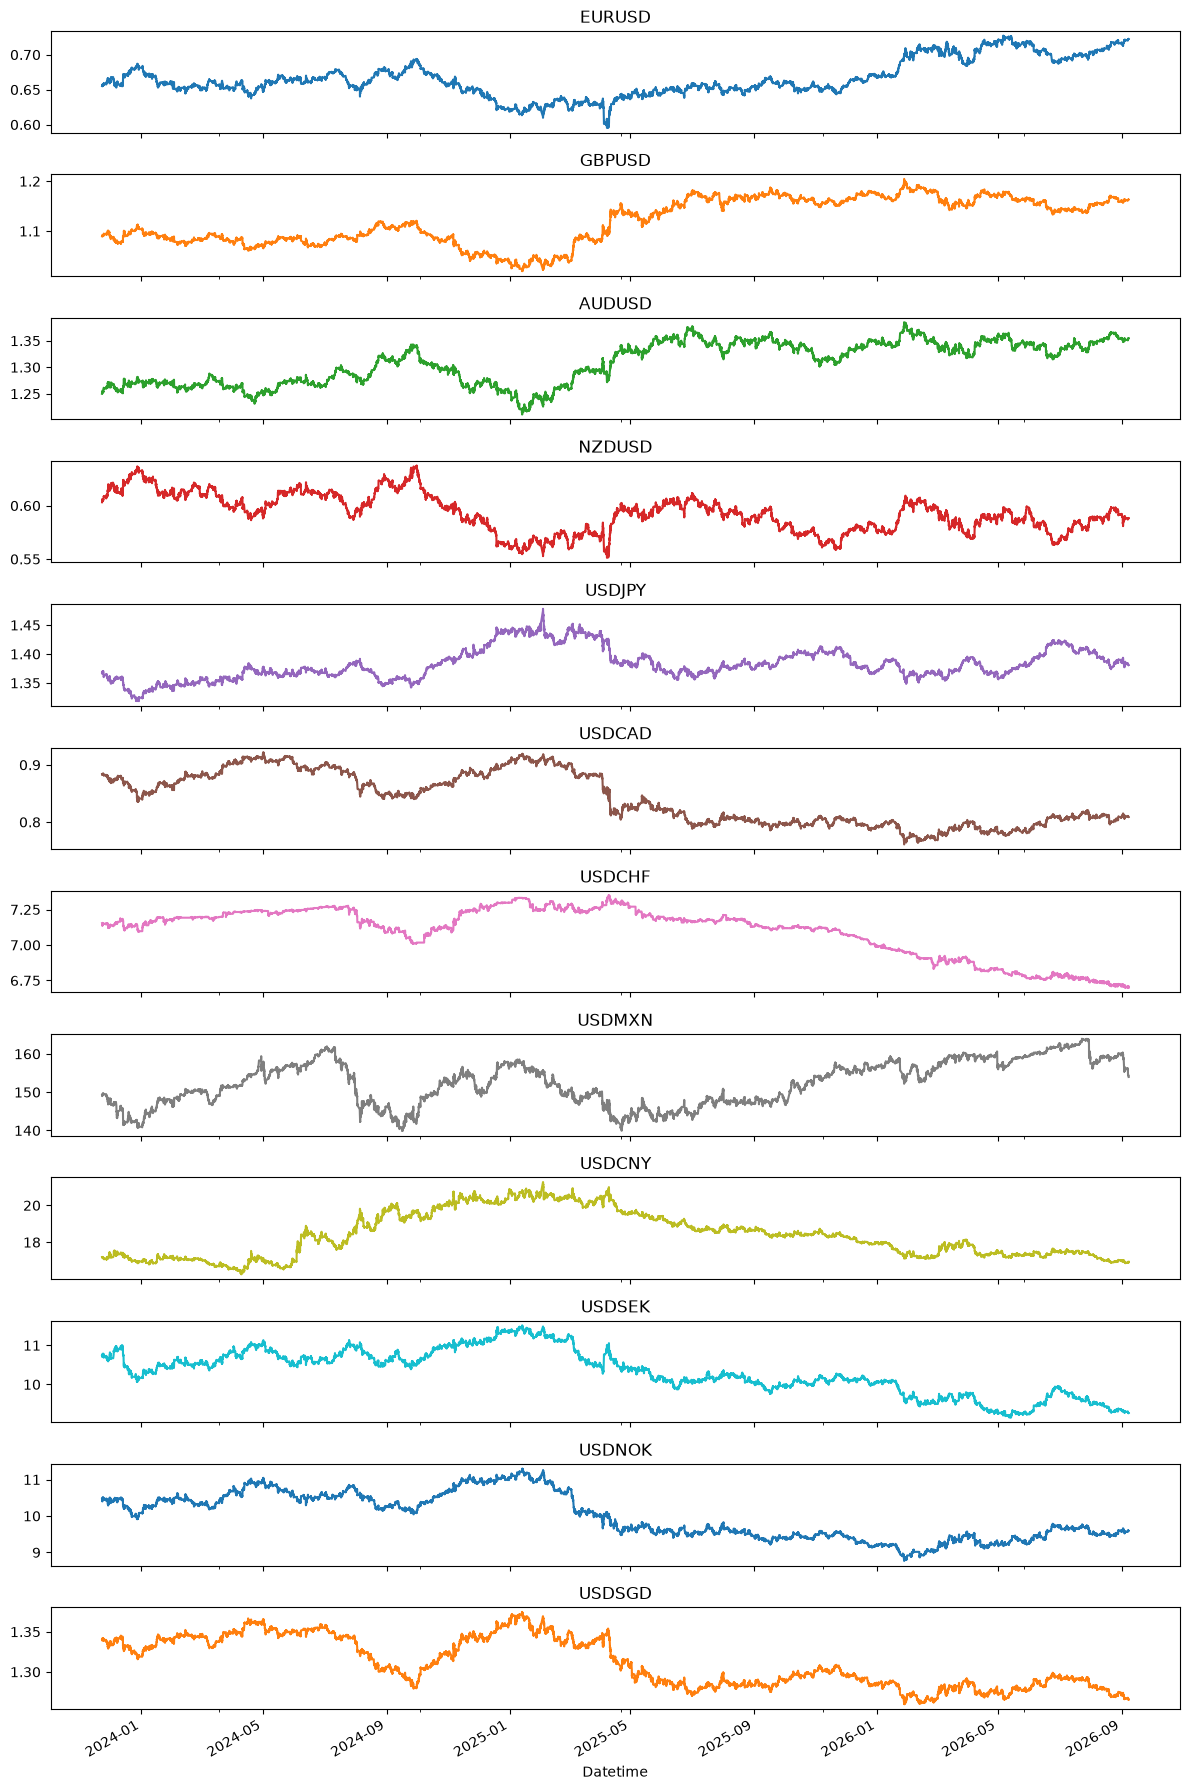

In [5]:
data.plot(subplots=True, figsize=(12, 18), title=list(data.columns), legend=False)
plt.tight_layout()
plt.show()

In [6]:
# Datos de entrenamiento y validacion

split_idx = int(len(data) * 0.70)
train = data.iloc[:split_idx]
test = data.iloc[split_idx:]

print(f"data: {data.shape} | train: {train.shape} | test: {test.shape}")

data: (17351, 12) | train: (12145, 12) | test: (5206, 12)


## Fase 2: Identificación Econométrica de Cointegración

Antes de armar cualquier señal de trading, hay que confirmar qué pares de divisas están relacionadas en el largo plazo (cointegrados), y no solo correlacionados por casualidad. Todo esto se calibra **únicamente con `train`**; el tramo de validación no se toca hasta el backtest final.

1. **ADF** sobre cada serie individual, para confirmar que son I(1) (no estacionarias por sí solas).
2. **Engle-Granger** par a par, para encontrar combinaciones de 2 divisas cuyo residuo sí sea estacionario.
3. **Johansen** sobre el universo completo, para detectar relaciones de equilibrio en canastas de 3+ divisas.

In [7]:
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.stats.multitest import multipletests
from itertools import combinations

In [8]:
def adf_test(series: pd.Series, name: str) -> dict:
    clean = series.dropna()
    if len(clean) == 0:
        raise ValueError(f"La serie '{name}' está vacía después de dropna() — revisa la Fase 1.")
    result = adfuller(clean, autolag='AIC')
    return {
        'serie': name,
        'adf_stat': result[0],
        'p_value': result[1],
        'es_I1': result[1] > 0.05,
    }

In [9]:
def engle_granger_pairs(data: pd.DataFrame, significance: float = 0.05) -> pd.DataFrame:
    """
    Corre la prueba de Engle-Granger sobre todas las combinaciones de 2 divisas.
    H0: NO hay cointegración. p-value bajo -> rechazamos H0 -> sí hay cointegración.
    """
    results = []
    for asset1, asset2 in combinations(data.columns, 2):
        score, p_value, _ = coint(data[asset1], data[asset2])
        results.append({
            'par': f"{asset1}-{asset2}",
            'asset1': asset1,
            'asset2': asset2,
            'p_value': p_value,
            'cointegrado': p_value < significance,
        })
    return pd.DataFrame(results).sort_values('p_value').reset_index(drop=True)

eg_results = engle_granger_pairs(train)
eg_results

,par,asset1,asset2,p_value,cointegrado
0,NZDUSD-USDJPY,NZDUSD,USDJPY,0.013269,True
1,AUDUSD-USDSGD,AUDUSD,USDSGD,0.044732,True
2,EURUSD-USDCHF,EURUSD,USDCHF,0.059022,False
3,GBPUSD-USDSEK,GBPUSD,USDSEK,0.064722,False
4,USDSEK-USDNOK,USDSEK,USDNOK,0.082467,False
...,...,...,...,...,...
61,USDCAD-USDCNY,USDCAD,USDCNY,0.913329,False
62,GBPUSD-USDMXN,GBPUSD,USDMXN,0.915605,False
63,GBPUSD-NZDUSD,GBPUSD,NZDUSD,0.951753,False
64,USDCAD-USDMXN,USDCAD,USDMXN,0.952995,False


In [10]:
n_tests = len(eg_results)
bonferroni_alpha = 0.05 / n_tests

print(f"Número de pares probados: {n_tests}")
print(f"Umbral Bonferroni ajustado: {bonferroni_alpha:.5f} (vs. 0.05 sin ajustar)")

eg_results['cointegrado_bonferroni'] = eg_results['p_value'] < bonferroni_alpha

pares_candidatos = eg_results[eg_results['cointegrado_bonferroni']]
print(f"\nPares que sobreviven la corrección: {len(pares_candidatos)}")
pares_candidatos

Número de pares probados: 66
Umbral Bonferroni ajustado: 0.00076 (vs. 0.05 sin ajustar)

Pares que sobreviven la corrección: 0


,par,asset1,asset2,p_value,cointegrado,cointegrado_bonferroni


In [11]:
rejected, p_adj, _, _ = multipletests(eg_results['p_value'], alpha=0.05, method='fdr_bh')

eg_results['p_value_fdr'] = p_adj
eg_results['cointegrado_fdr'] = rejected

pares_candidatos_fdr = eg_results[eg_results['cointegrado_fdr']]
print(f"Pares que sobreviven FDR (Benjamini-Hochberg): {len(pares_candidatos_fdr)}")
pares_candidatos_fdr

Pares que sobreviven FDR (Benjamini-Hochberg): 0


,par,asset1,asset2,p_value,cointegrado,cointegrado_bonferroni,p_value_fdr,cointegrado_fdr


In [12]:
def johansen_test(data: pd.DataFrame, det_order: int = 0, k_ar_diff: int = 1):
    """
    Prueba de Johansen sobre el universo completo. Detecta vectores de cointegración
    en canastas de 3+ divisas, no solo pares.
    det_order=0: sin tendencia determinista. k_ar_diff: rezagos en diferencias.
    """
    result = coint_johansen(data, det_order, k_ar_diff)

    trace_stat = result.lr1
    crit_vals_95 = result.cvt[:, 1]  # columna del 95% de confianza

    n_relations = sum(trace_stat > crit_vals_95)

    return pd.DataFrame({
        'trace_stat': trace_stat,
        'crit_val_95': crit_vals_95,
        'cointegrado': trace_stat > crit_vals_95,
    }), n_relations

johansen_results, n_relations = johansen_test(train, k_ar_diff=1)
print(f"Relaciones de cointegración detectadas (k_ar_diff=1): {n_relations}")
johansen_results

Relaciones de cointegración detectadas (k_ar_diff=1): 1


c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.venv-312-Investigacion_PCNM\Lib\site-packages\statsmodels\tsa\vector_ar\vecm.py:717: ComplexWarning: Casting complex values to real discards the imaginary part
  lr1[i] = -t * np.sum(tmp, 0)
c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.venv-312-Investigacion_PCNM\Lib\site-packages\statsmodels\tsa\vector_ar\vecm.py:718: ComplexWarning: Casting complex values to real discards the imaginary part
  lr2[i] = -t * np.log(1 - a[i])


,trace_stat,crit_val_95,cointegrado
0,369.616330,334.9795,True
1,274.030754,285.1402,False
2,207.684639,239.2468,False
3,158.186797,197.3772,False
4,112.819113,159.5290,False
5,80.066579,125.6185,False
6,54.573440,95.7542,False
7,35.253933,69.8189,False
8,22.133484,47.8545,False
9,11.892415,29.7961,False


In [13]:
for lag in [1, 4, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120]:
    _, n_rel = johansen_test(train, k_ar_diff=lag)
    print(f"k_ar_diff={lag:>2} -> relaciones detectadas: {n_rel}")

c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.venv-312-Investigacion_PCNM\Lib\site-packages\statsmodels\tsa\vector_ar\vecm.py:717: ComplexWarning: Casting complex values to real discards the imaginary part
  lr1[i] = -t * np.sum(tmp, 0)
c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.venv-312-Investigacion_PCNM\Lib\site-packages\statsmodels\tsa\vector_ar\vecm.py:718: ComplexWarning: Casting complex values to real discards the imaginary part
  lr2[i] = -t * np.log(1 - a[i])


k_ar_diff= 1 -> relaciones detectadas: 1


c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.venv-312-Investigacion_PCNM\Lib\site-packages\statsmodels\tsa\vector_ar\vecm.py:717: ComplexWarning: Casting complex values to real discards the imaginary part
  lr1[i] = -t * np.sum(tmp, 0)
c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.venv-312-Investigacion_PCNM\Lib\site-packages\statsmodels\tsa\vector_ar\vecm.py:718: ComplexWarning: Casting complex values to real discards the imaginary part
  lr2[i] = -t * np.log(1 - a[i])


k_ar_diff= 4 -> relaciones detectadas: 1


c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.venv-312-Investigacion_PCNM\Lib\site-packages\statsmodels\tsa\vector_ar\vecm.py:717: ComplexWarning: Casting complex values to real discards the imaginary part
  lr1[i] = -t * np.sum(tmp, 0)
c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.venv-312-Investigacion_PCNM\Lib\site-packages\statsmodels\tsa\vector_ar\vecm.py:718: ComplexWarning: Casting complex values to real discards the imaginary part
  lr2[i] = -t * np.log(1 - a[i])


...

c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.venv-312-Investigacion_PCNM\Lib\site-packages\statsmodels\tsa\vector_ar\vecm.py:717: ComplexWarning: Casting complex values to real discards the imaginary part
  lr1[i] = -t * np.sum(tmp, 0)
c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.venv-312-Investigacion_PCNM\Lib\site-packages\statsmodels\tsa\vector_ar\vecm.py:718: ComplexWarning: Casting complex values to real discards the imaginary part
  lr2[i] = -t * np.log(1 - a[i])


k_ar_diff=96 -> relaciones detectadas: 1


c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.venv-312-Investigacion_PCNM\Lib\site-packages\statsmodels\tsa\vector_ar\vecm.py:717: ComplexWarning: Casting complex values to real discards the imaginary part
  lr1[i] = -t * np.sum(tmp, 0)
c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.venv-312-Investigacion_PCNM\Lib\site-packages\statsmodels\tsa\vector_ar\vecm.py:718: ComplexWarning: Casting complex values to real discards the imaginary part
  lr2[i] = -t * np.log(1 - a[i])


k_ar_diff=108 -> relaciones detectadas: 1
k_ar_diff=120 -> relaciones detectadas: 1


c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.venv-312-Investigacion_PCNM\Lib\site-packages\statsmodels\tsa\vector_ar\vecm.py:717: ComplexWarning: Casting complex values to real discards the imaginary part
  lr1[i] = -t * np.sum(tmp, 0)
c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.venv-312-Investigacion_PCNM\Lib\site-packages\statsmodels\tsa\vector_ar\vecm.py:718: ComplexWarning: Casting complex values to real discards the imaginary part
  lr2[i] = -t * np.log(1 - a[i])


## Fase 3: Modelado Dinámico y Señales (Filtro de Kalman)

Dado que Johansen encontró una relación de cointegración sobre la canasta completa (no un par simple), el spread se construye con el vector de pesos (eigenvector) de esa relación. El Filtro de Kalman se usa aquí como un modelo de "nivel local": estima de forma recursiva el nivel de equilibrio dinámico μ_t del spread, en vez de un beta fijo entre dos activos. El Z-score se calcula sobre la desviación del spread respecto a ese nivel dinámico.

In [14]:
from pykalman import KalmanFilter

In [15]:
# Reemplaza best_lag por el k_ar_diff con el que obtuviste la única relación significativa
best_lag = 24 

johansen_full = coint_johansen(train, det_order=0, k_ar_diff=best_lag)
coint_vector = johansen_full.evec[:, 0]  # eigenvector de la primera (única) relación

weights = pd.Series(coint_vector, index=train.columns).sort_values(key=abs, ascending=False)
print("Pesos de la relación de cointegración (ordenados por magnitud):")
weights

Pesos de la relación de cointegración (ordenados por magnitud):


c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.venv-312-Investigacion_PCNM\Lib\site-packages\statsmodels\tsa\vector_ar\vecm.py:717: ComplexWarning: Casting complex values to real discards the imaginary part
  lr1[i] = -t * np.sum(tmp, 0)
c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.venv-312-Investigacion_PCNM\Lib\site-packages\statsmodels\tsa\vector_ar\vecm.py:718: ComplexWarning: Casting complex values to real discards the imaginary part
  lr2[i] = -t * np.log(1 - a[i])


USDJPY    163.966215-  0.000000j
NZDUSD    123.073389-  0.000000j
EURUSD     61.610418-  0.000000j
USDSGD    -56.169745+  0.000000j
USDCAD    -38.072744+  0.000000j
GBPUSD    -22.914732+  0.000000j
USDCHF     14.077705-  0.000000j
USDNOK      4.208836-  0.000000j
USDSEK     -2.395837+  0.000000j
AUDUSD     -2.087324+  0.000000j
USDCNY     -1.720174+  0.000000j
USDMXN     -0.191072+  0.000000j
dtype: complex128

c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.venv-312-Investigacion_PCNM\Lib\site-packages\matplotlib\cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.venv-312-Investigacion_PCNM\Lib\site-packages\matplotlib\cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


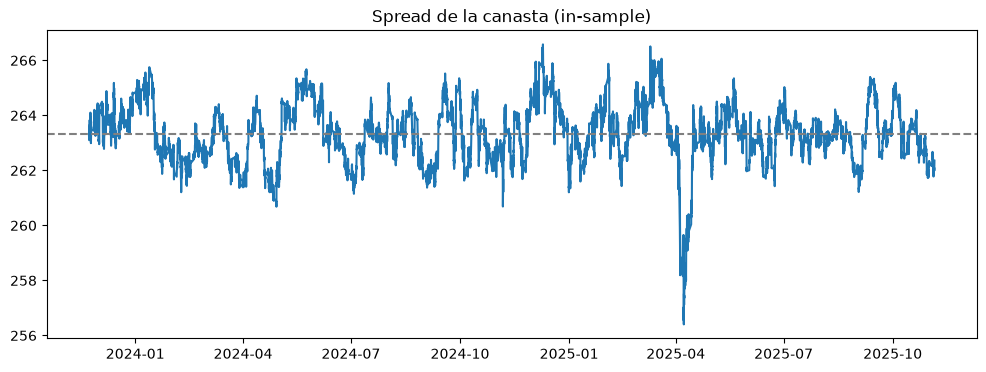

In [16]:
spread_train = train @ coint_vector
spread_test = test @ coint_vector

plt.figure(figsize=(12, 4))
plt.plot(spread_train.index, spread_train.values)
plt.title("Spread de la canasta (in-sample)")
plt.axhline(spread_train.mean(), color='gray', linestyle='--')
plt.show()

In [17]:
coint_vector = johansen_full.evec[:, 0]
coint_vector = np.real(coint_vector)  # <-- descarta la parte imaginaria (ruido numérico)

weights = pd.Series(coint_vector, index=train.columns).sort_values(key=abs, ascending=False)
weights

USDJPY    163.966215
NZDUSD    123.073389
EURUSD     61.610418
USDSGD    -56.169745
USDCAD    -38.072744
GBPUSD    -22.914732
USDCHF     14.077705
USDNOK      4.208836
USDSEK     -2.395837
AUDUSD     -2.087324
USDCNY     -1.720174
USDMXN     -0.191072
dtype: float64

In [18]:
print(coint_vector.dtype)
print(spread_train.dtype)
print(spread_test.dtype)

float64
complex128
complex128


In [19]:
coint_vector = np.real(johansen_full.evec[:, 0]).astype(np.float64)

spread_train = (train @ coint_vector).astype(np.float64)
spread_test = (test @ coint_vector).astype(np.float64)

print(spread_train.dtype, spread_test.dtype)  # deben decir float64

float64 float64


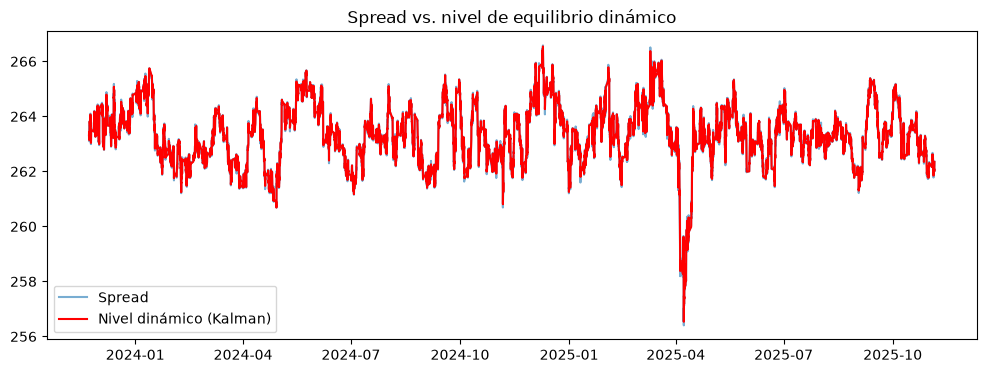

In [20]:
kf = KalmanFilter(
    transition_matrices=[1],
    observation_matrices=[1],
    initial_state_mean=spread_train.iloc[0],
    initial_state_covariance=1,
    observation_covariance=1,
    transition_covariance=0.01,
)

# Ajuste de los parámetros de ruido vía Expectation-Maximization sobre el tramo de entrenamiento
kf = kf.em(spread_train.values, n_iter=10)

state_means_train, state_covariances_train = kf.filter(spread_train.values)
mu_t_train = pd.Series(state_means_train.flatten(), index=spread_train.index)

plt.figure(figsize=(12, 4))
plt.plot(spread_train.index, spread_train.values, label='Spread', alpha=0.6)
plt.plot(mu_t_train.index, mu_t_train.values, label='Nivel dinámico (Kalman)', color='red')
plt.legend()
plt.title("Spread vs. nivel de equilibrio dinámico")
plt.show()

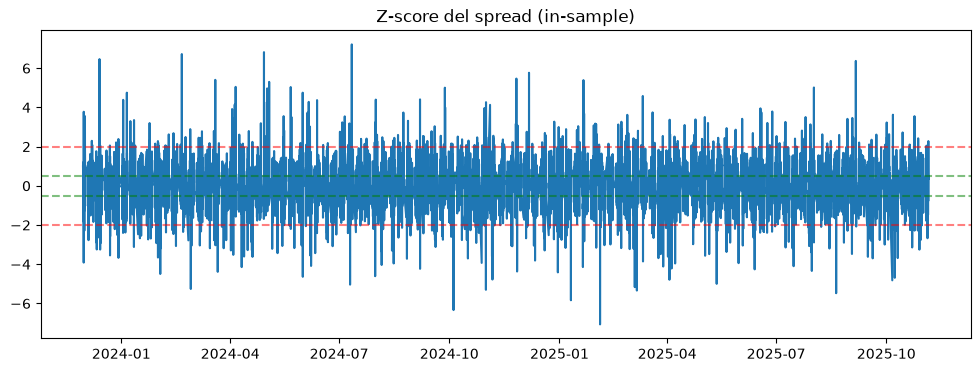

count    12026.000000
mean        -0.003742
std          1.006756
min         -7.068685
25%         -0.541777
50%          0.010129
75%          0.545628
max          7.214681
dtype: float64

In [21]:
window = 24 * 5  # ventana móvil para la desviación estándar (5 días de datos horarios)

residual_train = spread_train - mu_t_train
rolling_std_train = residual_train.rolling(window).std()

z_score_train = residual_train / rolling_std_train

plt.figure(figsize=(12, 4))
plt.plot(z_score_train.index, z_score_train.values)
plt.axhline(2, color='red', linestyle='--', alpha=0.5)
plt.axhline(-2, color='red', linestyle='--', alpha=0.5)
plt.axhline(0.5, color='green', linestyle='--', alpha=0.5)
plt.axhline(-0.5, color='green', linestyle='--', alpha=0.5)
plt.title("Z-score del spread (in-sample)")
plt.show()

z_score_train.describe()

In [22]:
print("Observation covariance (R):", kf.observation_covariance)
print("Transition covariance (Q):", kf.transition_covariance)
print("Ratio Q/R:", (kf.transition_covariance / kf.observation_covariance)[0][0])

pct_entrada = (z_score_train.abs() >= 2.0).mean() * 100
print(f"% del tiempo con |Z| >= 2.0: {pct_entrada:.1f}%")

Observation covariance (R): [[0.00594833]]
Transition covariance (Q): [[0.01443076]]
Ratio Q/R: 2.4260191966927303
% del tiempo con |Z| >= 2.0: 5.0%


% del tiempo con |Z| >= 2.0 (v2): 6.2%


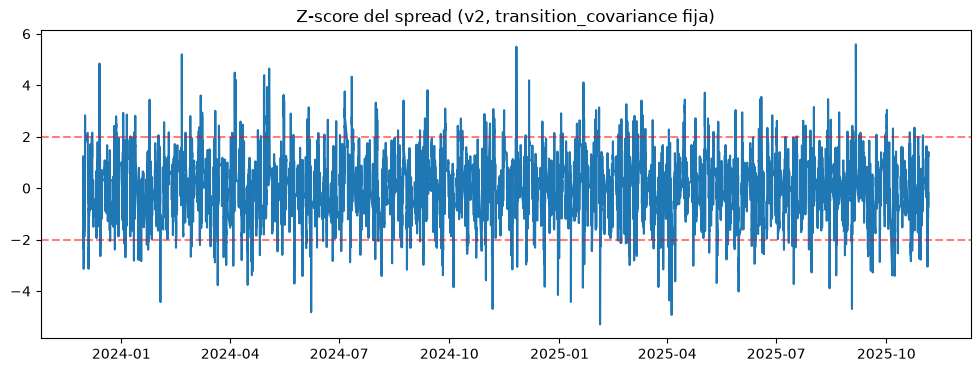

In [23]:
kf_v2 = KalmanFilter(
    transition_matrices=[1],
    observation_matrices=[1],
    initial_state_mean=spread_train.iloc[0],
    initial_state_covariance=1,
    observation_covariance=1,
    transition_covariance=0.001,  # fijo y más pequeño, no lo deja el EM libre
)

# Restringe el EM para que solo ajuste observation_covariance, no transition_covariance
kf_v2 = kf_v2.em(spread_train.values, n_iter=10, em_vars=['observation_covariance'])

state_means_v2, _ = kf_v2.filter(spread_train.values)
mu_t_v2 = pd.Series(state_means_v2.flatten(), index=spread_train.index)

residual_v2 = spread_train - mu_t_v2
z_score_v2 = residual_v2 / residual_v2.rolling(window).std()

pct_entrada_v2 = (z_score_v2.abs() >= 2.0).mean() * 100
print(f"% del tiempo con |Z| >= 2.0 (v2): {pct_entrada_v2:.1f}%")

plt.figure(figsize=(12, 4))
plt.plot(z_score_v2.index, z_score_v2.values)
plt.axhline(2, color='red', linestyle='--', alpha=0.5)
plt.axhline(-2, color='red', linestyle='--', alpha=0.5)
plt.title("Z-score del spread (v2, transition_covariance fija)")
plt.show()

In [24]:
z_score_v2.describe()

count    12026.000000
mean        -0.009480
std          1.053776
min         -5.294759
25%         -0.632099
50%          0.003009
75%          0.614308
max          5.586147
dtype: float64

In [25]:
print("Observation covariance (R) v2:", kf_v2.observation_covariance)
print("Transition covariance (Q) v2:", kf_v2.transition_covariance)
print("Ratio Q/R v2:", (kf_v2.transition_covariance / kf_v2.observation_covariance)[0][0])
print(f"Comparación directa: Q/R v1 = 2.43  vs.  Q/R v2 = {(kf_v2.transition_covariance / kf_v2.observation_covariance)[0][0]:.5f}")

Observation covariance (R) v2: [[0.03289099]]
Transition covariance (Q) v2: [[0.001]]
Ratio Q/R v2: 0.030403459511187735
Comparación directa: Q/R v1 = 2.43  vs.  Q/R v2 = 0.03040


In [26]:
kf = kf_v2
mu_t_train = mu_t_v2
z_score_train = z_score_v2

print("Kalman v2 fijado como versión oficial del proyecto.")

Kalman v2 fijado como versión oficial del proyecto.


## Fase 4: Reglas de Ejecución y Gestión de Riesgo

Se generan las señales de posición a partir del Z-score (entrada, salida, stop-loss), y se añade un filtro de régimen basado en un Modelo Oculto de Markov (HMM) que reduce el tamaño de la posición durante periodos de alta volatilidad — el HMM no decide qué operar, solo modula cuánto exponerse una vez que ya se decidió operar el spread encontrado en la Fase 2/3.

In [27]:
from hmmlearn.hmm import GaussianHMM

In [28]:
def generate_positions(z_score: pd.Series, entry: float = 2.0, exit: float = 0.5, stop_loss: float = 3.5) -> pd.Series:
    """
    Genera la serie de posiciones (-1, 0, 1) a partir del Z-score.
    position = 1  -> long el spread (se entró cuando z <= -entry, se espera que suba)
    position = -1 -> short el spread (se entró cuando z >= entry, se espera que baje)
    Es un proceso con estado (depende de la posición anterior), por eso el loop explícito.
    """
    position = 0
    positions = []
    for z in z_score:
        if position == 0:
            if z >= entry:
                position = -1
            elif z <= -entry:
                position = 1
        elif position == 1:
            if z >= -exit or z <= -stop_loss:
                position = 0
        elif position == -1:
            if z <= exit or z >= stop_loss:
                position = 0
        positions.append(position)
    return pd.Series(positions, index=z_score.index, name='position')

positions_train_raw = generate_positions(z_score_train)

print(positions_train_raw.value_counts())
print(f"\nNúmero de operaciones (cambios de posición desde 0): {(positions_train_raw.diff().abs() > 0).sum()}")

position
 0    10127
 1     1034
-1      984
Name: count, dtype: int64

Número de operaciones (cambios de posición desde 0): 614


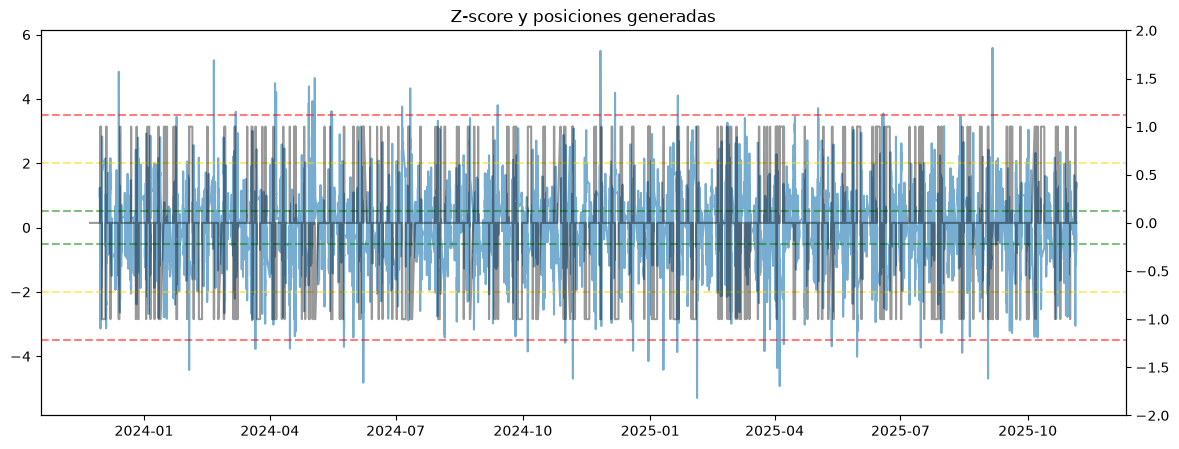

In [29]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(z_score_train.index, z_score_train.values, alpha=0.6, label='Z-score')
ax1.axhline(2, color='gold', linestyle='--', alpha=0.5)
ax1.axhline(-2, color='gold', linestyle='--', alpha=0.5)
ax1.axhline(3.5, color='red', linestyle='--', alpha=0.5)
ax1.axhline(-3.5, color='red', linestyle='--', alpha=0.5)
ax1.axhline(0.5, color='green', linestyle='--', alpha=0.5)
ax1.axhline(-0.5, color='green', linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
ax2.plot(positions_train_raw.index, positions_train_raw.values, color='black', alpha=0.4, label='Posición')
ax2.set_ylim(-2, 2)

ax1.set_title("Z-score y posiciones generadas")
plt.show()

In [30]:
# Volatilidad realizada del spread como feature para detectar régimen
spread_returns_train = spread_train.diff().dropna()
realized_vol_train = spread_returns_train.rolling(24).std().dropna()  # ventana de 24h

X_train_hmm = realized_vol_train.values.reshape(-1, 1)

hmm_model = GaussianHMM(n_components=2, covariance_type='diag', n_iter=1000, random_state=42)
hmm_model.fit(X_train_hmm)

regimes_train = pd.Series(hmm_model.predict(X_train_hmm), index=realized_vol_train.index)

# Identificar cuál de los 2 estados es "alta volatilidad" comparando las medias aprendidas
means = hmm_model.means_.flatten()
high_vol_state = int(np.argmax(means))
print(f"Medias de volatilidad por estado: {means}")
print(f"Estado de alta volatilidad: {high_vol_state}")

regime_label_train = regimes_train.map({high_vol_state: 'alta_volatilidad', 1 - high_vol_state: 'calmo'})
print(regime_label_train.value_counts(normalize=True) * 100)

Medias de volatilidad por estado: [0.19852664 0.11323146]
Estado de alta volatilidad: 0
calmo               64.087122
alta_volatilidad    35.912878
Name: proportion, dtype: float64


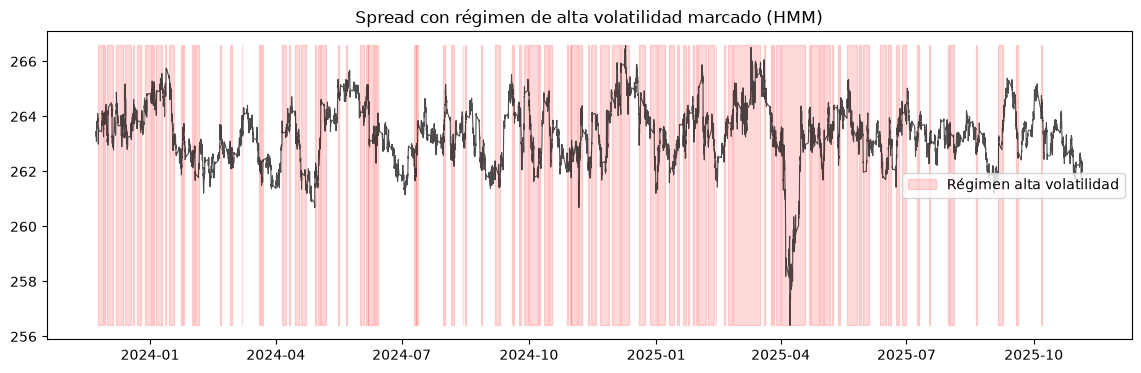

In [31]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(spread_train.index, spread_train.values, color='black', alpha=0.7, linewidth=0.8)

alta_vol_mask = regime_label_train.reindex(spread_train.index) == 'alta_volatilidad'
ax.fill_between(spread_train.index, spread_train.min(), spread_train.max(),
                 where=alta_vol_mask.fillna(False), color='red', alpha=0.15, label='Régimen alta volatilidad')

ax.set_title("Spread con régimen de alta volatilidad marcado (HMM)")
ax.legend()
plt.show()

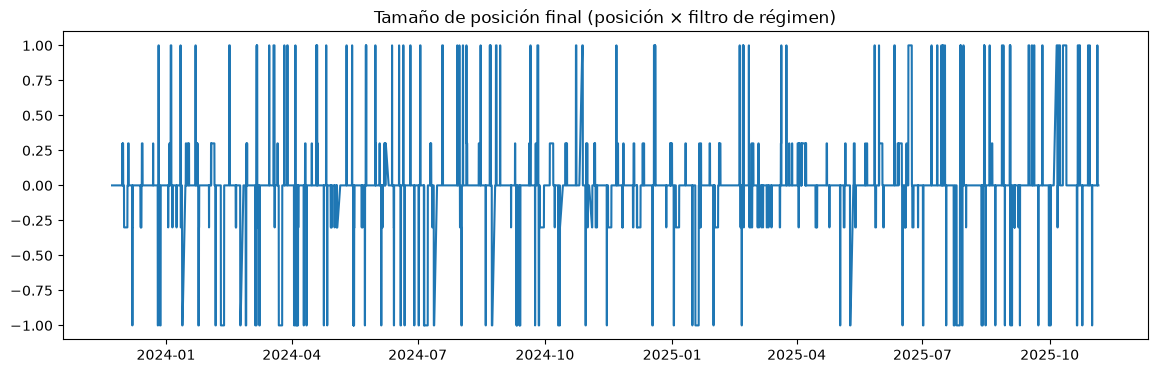

In [32]:
regime_aligned_train = regime_label_train.reindex(positions_train_raw.index).ffill().bfill()

# Reduce exposición al 30% en régimen de alta volatilidad, en vez de apagar el sistema por completo
size_multiplier_train = regime_aligned_train.map({'alta_volatilidad': 0.3, 'calmo': 1.0})

position_size_train = positions_train_raw * size_multiplier_train
position_size_train.name = 'position_size'

plt.figure(figsize=(14, 4))
plt.plot(position_size_train.index, position_size_train.values)
plt.title("Tamaño de posición final (posición × filtro de régimen)")
plt.show()

In [33]:
# Duración de cada racha continua en el mismo régimen
regime_runs = (regime_label_train != regime_label_train.shift()).cumsum()
run_lengths = regime_label_train.groupby(regime_runs).size()

print("Duración promedio de cada racha de régimen (en observaciones horarias):")
print(run_lengths.describe())

Duración promedio de cada racha de régimen (en observaciones horarias):
count    201.000000
mean      60.303483
std       73.425285
min        5.000000
25%       24.000000
50%       32.000000
75%       65.000000
max      508.000000
dtype: float64


In [34]:
# 1. Usar log-volatilidad en vez de volatilidad cruda (la std tiene cola derecha pesada,
#    el HMM Gaussiano ajusta mejor con algo más simétrico)
log_vol_train = np.log(realized_vol_train.replace(0, np.nan)).dropna()
X_train_hmm_v2 = log_vol_train.values.reshape(-1, 1)

hmm_model_v2 = GaussianHMM(n_components=2, covariance_type='diag', n_iter=1000, random_state=42)
hmm_model_v2.fit(X_train_hmm_v2)

# 2. Forzar que el modelo prefiera quedarse en el mismo estado (matriz de transición "pegajosa")
#    hmmlearn no tiene un parámetro directo para esto, pero podemos inicializar transmat_prior alto
hmm_model_v2.transmat_ = np.array([[0.98, 0.02], [0.02, 0.98]])  # alta probabilidad de permanecer

regimes_train_v2 = pd.Series(hmm_model_v2.predict(X_train_hmm_v2), index=log_vol_train.index)
means_v2 = hmm_model_v2.means_.flatten()
high_vol_state_v2 = int(np.argmax(means_v2))
regime_label_train_v2 = regimes_train_v2.map({high_vol_state_v2: 'alta_volatilidad', 1 - high_vol_state_v2: 'calmo'})

regime_runs_v2 = (regime_label_train_v2 != regime_label_train_v2.shift()).cumsum()
run_lengths_v2 = regime_label_train_v2.groupby(regime_runs_v2).size()
print(run_lengths_v2.describe())

count    209.000000
mean      57.995215
std       66.842344
min        5.000000
25%       23.000000
50%       32.000000
75%       67.000000
max      438.000000
dtype: float64


## Fase 5: Backtesting y Benchmarking

Se aplica el pipeline completo (spread → Kalman → Z-score → posición → filtro HMM) sobre el tramo out-of-sample (`test`), usando los modelos ya entrenados en `train` sin reajustarlos — así el resultado refleja qué tan bien generaliza el sistema a datos que nunca vio. Se incorporan costos de transacción y se compara el desempeño ajustado por riesgo contra el MSCI World.

In [35]:
import quantstats as qs

In [36]:
# 1. Spread out-of-sample con el mismo vector de cointegración (ya calculado en Fase 3)
# spread_test ya existe desde la Fase 3; confirmamos su dtype
print(spread_test.dtype)

# 2. Nivel dinámico del Kalman YA ENTRENADO (kf = kf_v2), aplicado a test sin refit
state_means_test, _ = kf.filter(spread_test.values)
mu_t_test = pd.Series(state_means_test.flatten(), index=spread_test.index)

# 3. Z-score out-of-sample (misma ventana que en train)
residual_test = spread_test - mu_t_test
z_score_test = residual_test / residual_test.rolling(window).std()

# 4. Posiciones con las mismas reglas de la Fase 4
positions_test_raw = generate_positions(z_score_test)

# 5. Régimen HMM YA ENTRENADO, aplicado a test sin refit
spread_returns_test = spread_test.diff().dropna()
realized_vol_test = spread_returns_test.rolling(24).std().dropna()
log_vol_test = np.log(realized_vol_test.replace(0, np.nan)).dropna()

regimes_test = pd.Series(hmm_model_v2.predict(log_vol_test.values.reshape(-1, 1)), index=log_vol_test.index)
regime_label_test = regimes_test.map({high_vol_state_v2: 'alta_volatilidad', 1 - high_vol_state_v2: 'calmo'})
regime_aligned_test = regime_label_test.reindex(positions_test_raw.index).ffill().bfill()

size_multiplier_test = regime_aligned_test.map({'alta_volatilidad': 0.3, 'calmo': 1.0})
position_size_test = (positions_test_raw * size_multiplier_test).fillna(0)
position_size_test.name = 'position_size'

print(f"% del tiempo con posición activa (test): {(position_size_test != 0).mean()*100:.1f}%")

float64
% del tiempo con posición activa (test): 14.9%


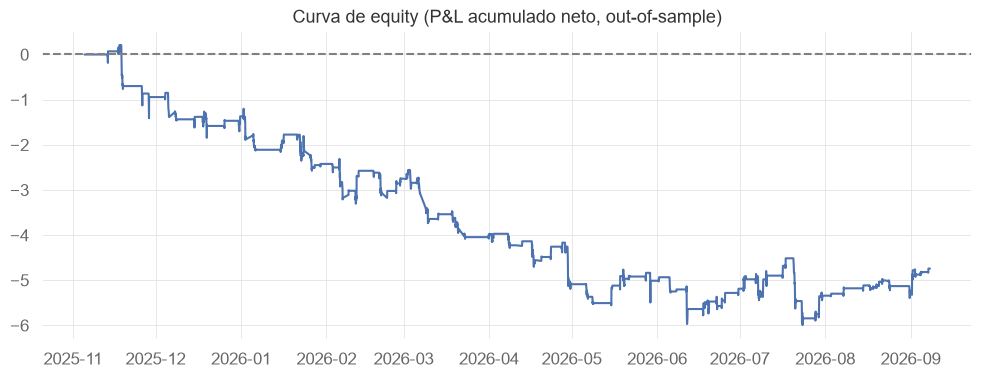

P&L bruto acumulado: 4.4497
Costos totales:      9.1917
P&L neto acumulado:  -4.7420


In [37]:
def run_backtest(spread: pd.Series, position_size: pd.Series, weights: np.ndarray, cost_bps: float = 1.0):
    """
    P&L aproximado: la posición se decide con la información hasta t-1 y se aplica
    al cambio del spread en t (shift(1) evita look-ahead).
    Costos de transacción proporcionales al turnover y al tamaño total de la canasta operada.
    """
    position_lagged = position_size.shift(1).fillna(0)
    spread_diff = spread.diff().fillna(0)

    pnl_gross = position_lagged * spread_diff

    turnover = position_size.diff().abs().fillna(0)
    costs = turnover * np.abs(weights).sum() * (cost_bps / 10000)

    pnl_net = pnl_gross - costs
    return pnl_net, pnl_gross, costs

pnl_net_test, pnl_gross_test, costs_test = run_backtest(spread_test, position_size_test, coint_vector, cost_bps=1.0)

equity_curve = pnl_net_test.cumsum()

plt.figure(figsize=(12, 4))
plt.plot(equity_curve.index, equity_curve.values)
plt.title("Curva de equity (P&L acumulado neto, out-of-sample)")
plt.axhline(0, color='gray', linestyle='--')
plt.show()

print(f"P&L bruto acumulado: {pnl_gross_test.sum():.4f}")
print(f"Costos totales:      {costs_test.sum():.4f}")
print(f"P&L neto acumulado:  {pnl_net_test.sum():.4f}")

In [41]:
# 1. Descarga diaria de URTH (mucho más confiable que intradía)
benchmark_daily = yf.download('URTH', period='729d', interval='1d', progress=False)['Close']
if isinstance(benchmark_daily, pd.DataFrame):
    benchmark_daily = benchmark_daily.iloc[:, 0]

if benchmark_daily.index.tz is not None:
    benchmark_daily.index = benchmark_daily.index.tz_localize(None)

print("Shape:", benchmark_daily.shape)
print("NaNs:", benchmark_daily.isna().sum())
benchmark_daily.describe()

Shape: (729,)
NaNs: 0


count    729.000000
mean     161.371021
std       25.140224
min      109.890610
25%      142.356018
50%      156.720535
75%      182.325592
max      211.509995
Name: URTH, dtype: float64

In [43]:
# 2. Agregar el P&L de la estrategia (que está en horas) a nivel diario
pnl_net_daily = pnl_net_test.copy()
if pnl_net_daily.index.tz is not None:
    pnl_net_daily.index = pnl_net_daily.index.tz_localize(None)

pnl_net_daily = pnl_net_daily.resample('D').sum()
pnl_net_daily = pnl_net_daily[pnl_net_daily.index.isin(benchmark_daily.index) | (pnl_net_daily != 0)]

# 3. Retornos de estrategia y benchmark, alineados por fecha (día calendario)
strategy_returns_daily = (pnl_net_daily / notional_capital).rename('strategy')
benchmark_returns_daily = benchmark_daily.pct_change().rename('benchmark')

common_index = strategy_returns_daily.index.intersection(benchmark_returns_daily.index)
strategy_returns_daily = strategy_returns_daily.loc[common_index].fillna(0)
benchmark_returns_daily = benchmark_returns_daily.loc[common_index].fillna(0)

print(f"Observaciones diarias en común: {len(common_index)}")
print(f"Valores de estrategia distintos de 0: {(strategy_returns_daily != 0).sum()}")
print(f"Valores de benchmark distintos de 0: {(benchmark_returns_daily != 0).sum()}")

Observaciones diarias en común: 209
Valores de estrategia distintos de 0: 112
Valores de benchmark distintos de 0: 209


In [44]:
metrics = pd.DataFrame({
    'CAGR': [qs.stats.cagr(strategy_returns_daily), qs.stats.cagr(benchmark_returns_daily)],
    'Sharpe': [qs.stats.sharpe(strategy_returns_daily), qs.stats.sharpe(benchmark_returns_daily)],
    'Sortino': [qs.stats.sortino(strategy_returns_daily), qs.stats.sortino(benchmark_returns_daily)],
    'Max Drawdown': [qs.stats.max_drawdown(strategy_returns_daily), qs.stats.max_drawdown(benchmark_returns_daily)],
}, index=['Estrategia', 'MSCI World (URTH)'])

beta = qs.stats.greeks(strategy_returns_daily, benchmark_returns_daily)['beta']
metrics.loc['Estrategia', 'Beta vs. MSCI World'] = beta

metrics

,CAGR,Sharpe,Sortino,Max Drawdown,Beta vs. MSCI World
Estrategia,-0.246050,-2.099410,-2.372948,-0.254970,-0.086445
MSCI World (URTH),0.199768,1.416968,2.138641,-0.090607,NaN


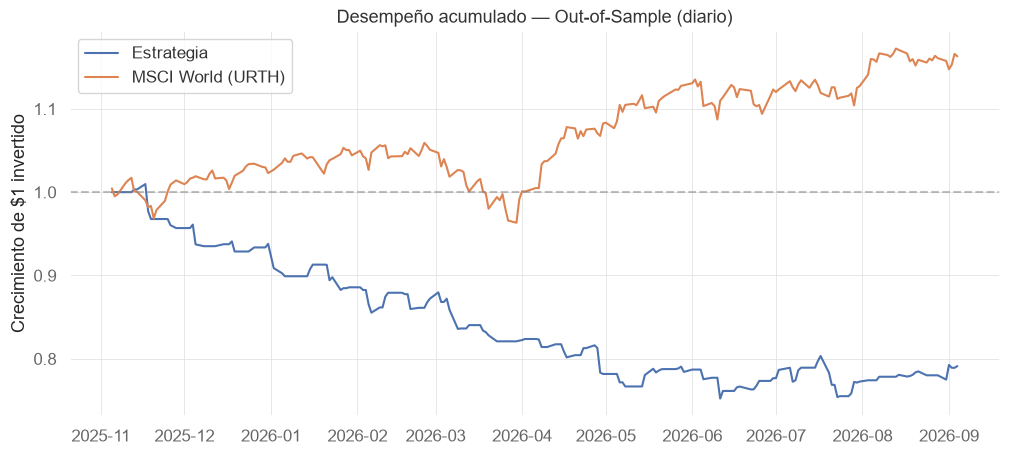

In [45]:
strategy_cum_daily = (1 + strategy_returns_daily).cumprod()
benchmark_cum_daily = (1 + benchmark_returns_daily).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(strategy_cum_daily.index, strategy_cum_daily.values, label='Estrategia', linewidth=1.5)
plt.plot(benchmark_cum_daily.index, benchmark_cum_daily.values, label='MSCI World (URTH)', linewidth=1.5)
plt.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
plt.legend()
plt.title("Desempeño acumulado — Out-of-Sample (diario)")
plt.ylabel("Crecimiento de $1 invertido")
plt.show()

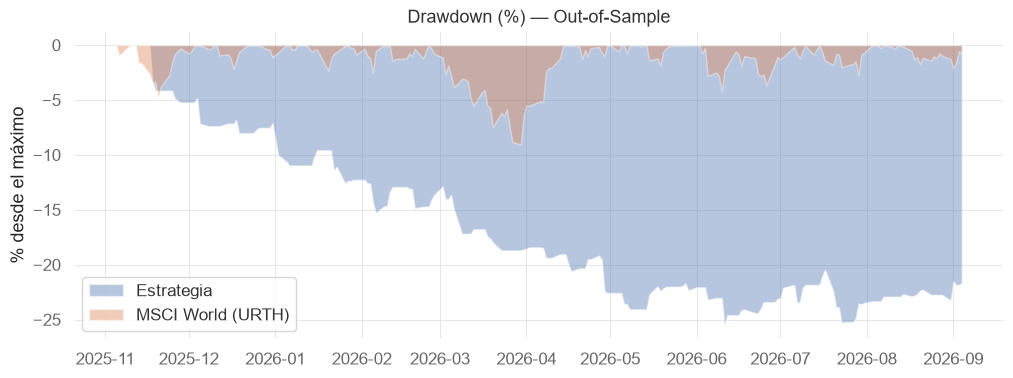

In [46]:
strategy_dd = qs.stats.to_drawdown_series(strategy_returns_daily)
benchmark_dd = qs.stats.to_drawdown_series(benchmark_returns_daily)

plt.figure(figsize=(12, 4))
plt.fill_between(strategy_dd.index, strategy_dd.values * 100, 0, alpha=0.4, label='Estrategia')
plt.fill_between(benchmark_dd.index, benchmark_dd.values * 100, 0, alpha=0.4, label='MSCI World (URTH)')
plt.legend()
plt.title("Drawdown (%) — Out-of-Sample")
plt.ylabel("% desde el máximo")
plt.show()